# **Математический анализ I. Лабораторная работа №2. Часть 1**

## **<font color=#10A1C4> *Содержание:</font>***

### **<font color=#10A1C4>*Содержание по задачам:</font>***

1. [Раздел: интерполяция](#interpolation_1):
- [Задача 1](#task_1) <br>
- [Задача 2](#task_2) <br>
2. [Раздел: функции нескольких переменных:](#function_several_variables)
- [Задача 3](#task_3) <br>
- [Задача 4](#task_4) <br>
- [Задача 5](#task_5) <br>


<a name="interpolation_1"></a>
## **<font color=#02AF02>1. Раздел: интерполяция</font>**

<a name="task_1"></a>
**<font color=#FF5EDD>Задача 1**</font>

Вы - аналитик в хедж-фонде. В системе сбора данных произошел технический сбой: часть котировок Биткоина (BTC-USD) была утеряна. Для корректной работы торговых роботов необходимо восстановить пропущенные значения.

<font color=#FF5EDD>*Ваша задача:*</font> Провести исследование и определить, какой метод интерполяции является наиболее надежным в разных рыночных условиях (Вам даны два разных периода), и какой из них создает максимальные риски для капитала компании.

<font color=#FF5EDD>Параметры исследования</font> (значения их можно менять):

* Количество анализируемых торговых дней (сколько последних точек периода берем (None = весь период)) (`S_SIZE`): 100 точек (дней).
* Количество пропусков (переменная, определяющая количество искусственно созданных пропусков (дырок)) (`n_missing`): 15 точек
* Сценарии: Сравнить Period1 и Period2.

Подготовка данных: используйте выданную функцию `prepare_data_and_sabotage`.

<font color=#FF5EDD>***Этап 1: Реализация методов интерполяции***</font>

используя библиотеку `Pandas` (метод `.interpolate()`), восстановите данные в колонке `Corrupted` тремя способами:
* Линейная интерполяция (linear) — соединение точек прямыми линиями.
* Кубический сплайн (spline, order=3) — построение гладкой кривой.
* Полином 5-й степени (polynomial или spline, order=5) — попытка учесть сложные изгибы тренда.

<font color=#FF5EDD>***Этап 2: Расчет метрик точности***</font>

Для каждого метода рассчитайте ошибки только в местах пропусков (используйте mask):
* <font color=#FF5EDD>***RMSE***</font> (Root Mean Squared Error): среднеквадратичная ошибка. Показывает общее качество восстановления. Формула: $\sqrt{\frac{1}{N} \sum (y_{real} - y_{pred})^2}$ Поскольку ошибка возводится в квадрат, RMSE жестоко штрафует за большие промахи. Когда важна: Если вы боитесь редких, но метких ошибок модели.
* <font color=#FF5EDD>***Max Error***</font> (Worst Case Scenario): максимальное отклонение восстановленной цены от реальной в одной точке. Формула: $max(|y_{real} - y_{pred}|)$ В трейдинге это критическая метрика: огромная ошибка в одной точке может привести к ложному срабатыванию стоп-лосса или ликвидации позиции. Это главная метрика риска.
* (по желанию можно добавить MAE (Mean Absolute Error): Формула: $\frac{1}{N} \sum |y_{real} - y_{pred}|$ Средняя ошибка в долларах. Сколько мы теряем в среднем на каждой сделке из-за кривых данных?)

<font color=#FF5EDD>***Этап 3: Тестирование***</font>

Напишите цикл, который будет увеличивать количество пропусков (n_missing) от 5 до 40 с шагом 5. Для каждого шага рассчитайте RMSE и Max Error для всех трех методов. Сохраните результаты в структуру данных (например, словарь или DataFrame).

<font color=#FF5EDD>***Этап 4: Визуализация результатов***</font>

Необходимо построить два типа графиков:
* <font color=#FF5EDD>***График цен:***</font> Два графика (для Period1 и Period2). Сравнение оригинала и всех трех линий интерполяции на одном окне (чтобы увидеть «галлюцинации» моделей глазами). Отменить крестиками точки, которые мы искуственно убрали (наши потерянные данные)
* <font color=#FF5EDD>***График деградации точности:***</font> Два графика (для Period1 и Period2), где по горизонтали — количество пропусков, а по вертикали — ошибки (RMSE на основной оси, Max Error на вспомогательной).

<font color=#FF5EDD>**Вопросы:**</font>

1. Сравните два периода. Кратко опиши отличия.

2. Риск-менеджмент: Представьте, что на оси Y это цена вашего актива. Какое максимальное отклонение в долларах (Max Error) допустил Сплайн? Если бы вы торговали с кредитным плечом, привела бы такая "галлюцинация" алгоритма к банкротству?

3. Эффект «Перелета»: Найдите на графике место, где цена резко меняла направление (V-образный разворот). Как повел себя Сплайн и Полином? Нарисовали ли они цену ниже реального дна или выше реального пика?

4. Края данных: Что происходит с Полиномом и Сплайном в самом начале и в самом конце графика? Насколько им можно доверять без "соседей" с обеих сторон?

5.  RMSE информативность: Может ли быть так, что средняя ошибка (RMSE) у сплайна ниже, чем у линейной интерполяции, но при этом торговать по его данным опаснее?

6. Бритва Оккама: Есть ли смысл использовать сложные методы (сплайны), если линейная интерполяция дает сопоставимую или лучшую точность при меньшем риске огромных Max Error?

7. Как методы ведут себя на более коротких отрезках данных? Повлияет ли это на точность полиномов? Попробуйте поиграться с S_SIZE (например, измените его на 50), чтобы это увидеть

8. Какой метод Вы бы выбрали для работы в условиях высокой волатильности и почему? 
Какой метод Вы бы внедрили в реальную торговую систему фонда? Обоснуйте выбор.

*Примечание: для удобства можете разбить свое решение на несколько ячеек.* 


Загрузка Period1: с 2023-04-01 по 2023-09-01...


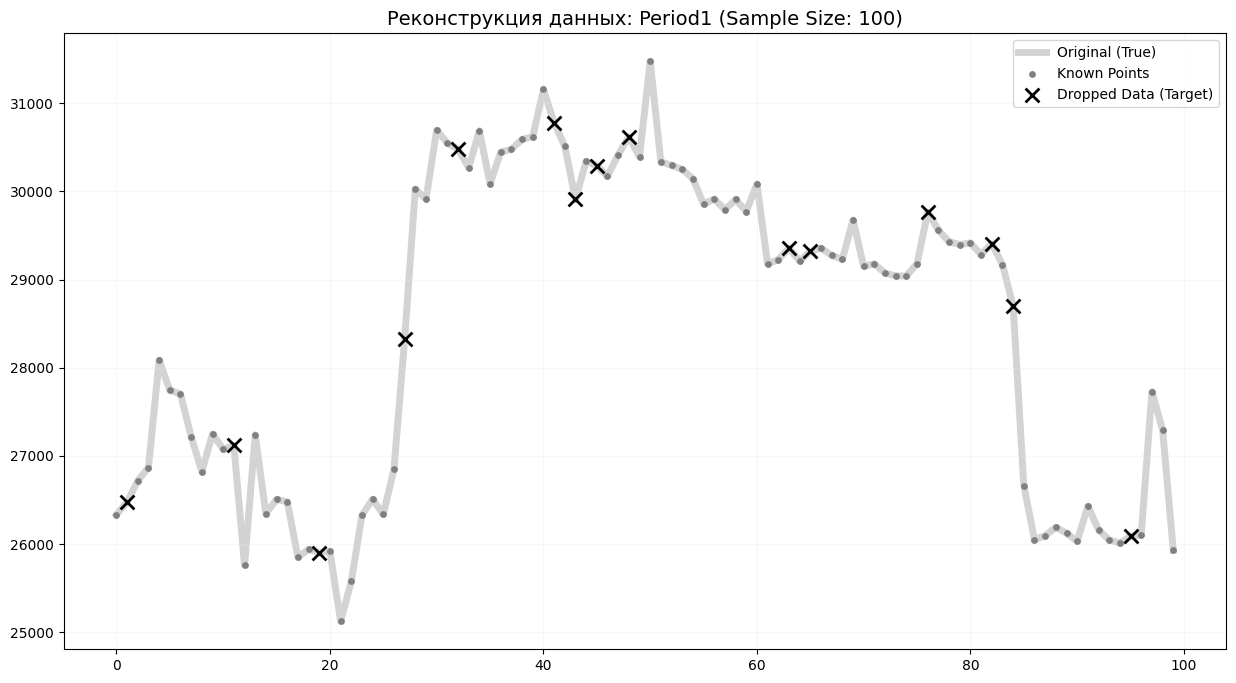

Загрузка Period1: с 2023-04-01 по 2023-09-01...


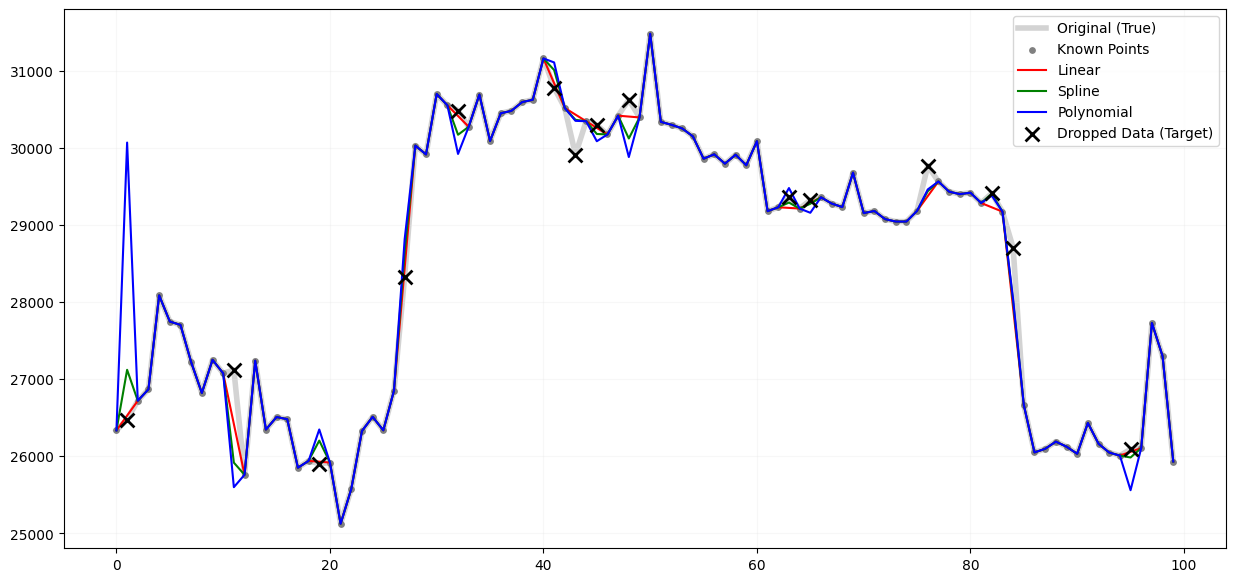

Загрузка Period2: с 2022-05-01 по 2022-07-01...


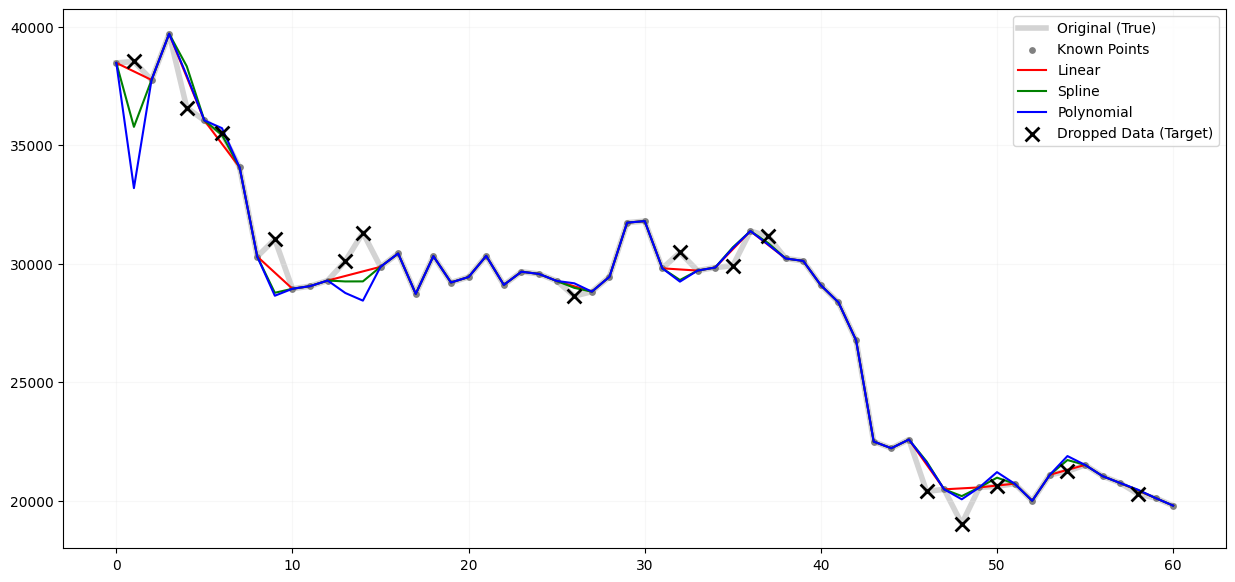

Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...


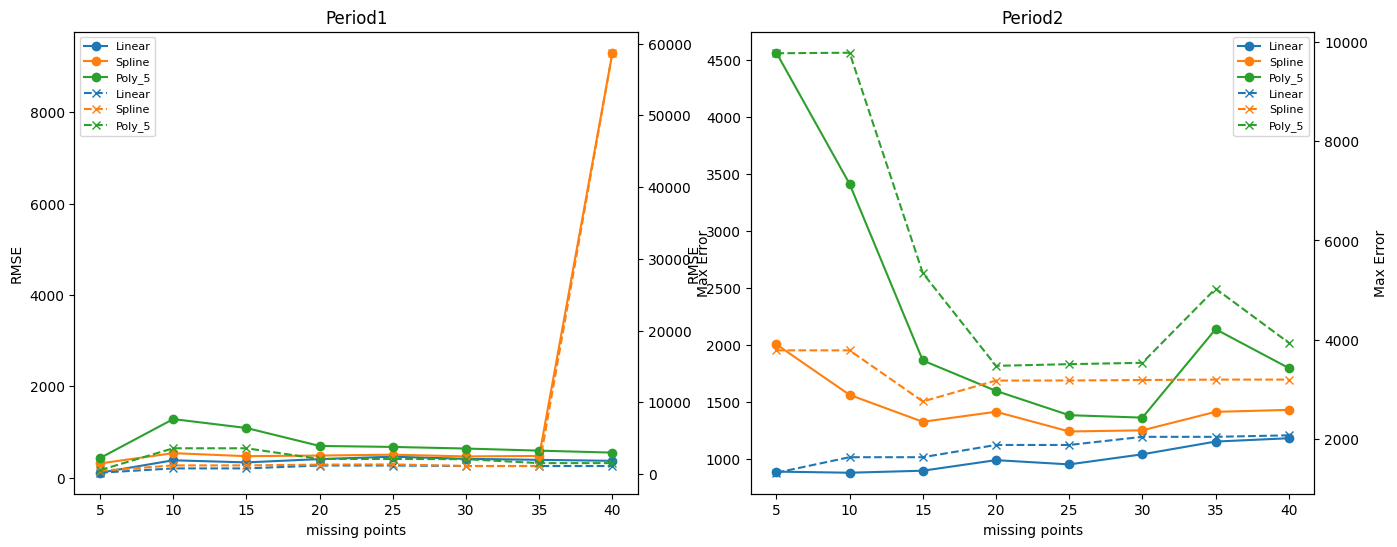

In [3]:
# не забудьте скачать все библиотеки (!pip install)
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, max_error

# Настройки графиков
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'grid.color': '#E6E6E6'})

# БЛОК 1: ПОДГОТОВКА ДАННЫХ (НЕ МЕНЯТЬ)

MY_SCENARIOS = {
    'Period1': ('2023-04-01', '2023-09-01'), 
    'Period2': ('2022-05-01', '2022-07-01') 
}

def prepare_data_and_sabotage(variant, scenarios_dict, n_missing, sample_size=None, seed=42):
    """
    variant: 'Period1' или 'Period2'
    n_missing: количество точек для удаления
    sample_size: сколько последних точек периода взять (None = весь период)
    """
    start_dt, end_dt = scenarios_dict[variant]
    
    print(f"Загрузка {variant}: с {start_dt} по {end_dt}...")
    data = yf.download('BTC-USD', start=start_dt, end=end_dt, progress=False)
    
    if data.empty:
        raise ValueError("Данные не скачались!")
        
    df = data.reset_index()[['Close']].rename(columns={'Close': 'Original'})
    
    # Обрезка по размеру выборки, если указано
    if sample_size is not None:
        df = df.tail(sample_size).reset_index(drop=True)
    
    # Саботаж
    np.random.seed(seed)
    df_work = df.copy()
    drop_idx = np.random.choice(df.index[1:-1], size=n_missing, replace=False)
    
    df_work['Corrupted'] = df_work['Original']
    df_work.loc[drop_idx, 'Corrupted'] = np.nan
    
    mask = df_work['Corrupted'].isna()
    return df_work, mask, drop_idx


# БЛОК 2: ВАШЕ исследование

# инициализация (меняйте значения этих трех переменных)
CASE = 'Period1' 
N_DROPPED = 15
S_SIZE = 100    # например: попробуйте поменять на 50 или оставить None

df, missing_mask, dropped_indices = prepare_data_and_sabotage(
    CASE, MY_SCENARIOS, n_missing=N_DROPPED, sample_size=S_SIZE
)

# КОД ниже можно менять координально, если нужно

# интерполяция (Задание)
# Реализуйте заполнение пропусков в df['Linear'], df['Spline'] и df['Poly_5']

# Подсказка: 1. Линейная интерполяция используйте метод method='linear' Код: df['column'].interpolate(method='linear')
# Почему: В библиотеке Pandas это самый стабильный алгоритм. Он не требует дополнительных настроек и корректно работает даже на краях данных.
# 2. Кубический сплайн (Для сравнения) используйте методы method='spline' или method='cubic'. Код: df['column'].interpolate(method='spline', order=3)
# Важное примечание: Для работы этого метода в Python должна быть установлена библиотека Scipy (pip install scipy), так как Pandas обращается к ней для сложных математических расчетов.
# для Spline и Poly используйте метод 'spline' или 'polynomial' с указанием order

# ... Ваш код здесь ...
df["Linear"] = df['Corrupted'].interpolate(method="linear")
df["Spline"] = df['Corrupted'].interpolate(method="spline", order=3)
df["Poly_5"] = df['Corrupted'].interpolate(method="polynomial", order=5)
    
# Визуализация (Задание)
plt.figure(figsize=(15, 8))

# Слой 1: истинная цена (фон) (можно менять)
plt.plot(df.index, df['Original'], color='lightgray', linewidth=5, label='Original (True)', zorder=1)

# Слой 2: известные данные (точки) (можно менять)
plt.scatter(df.index, df['Corrupted'], color='gray', s=15, label='Known Points', zorder=2)

# Слой 3: интерполяции (линии)
# Отрисуйте все три метода: Linear (blue), Spline (red, dashed), Poly_5 (green, dotted)
# ... Ваш код здесь ...

# Слой 4: Потерянные данные (крестики) (можно менять)
plt.scatter(dropped_indices, df.loc[dropped_indices, 'Original'], 
            color='black', marker='x', s=100, linewidth=2, label='Dropped Data (Target)', zorder=10)

# можно менять
plt.title(f"Реконструкция данных: {CASE} (Sample Size: {S_SIZE})", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Метрики (задание)
# Рассчитайте RMSE и Max Error для каждого метода
# Постройте линейных график этих метрик
# ВАЖНО: Считайте ошибки ТОЛЬКО в точках из missing_mask!

#для всех пропущенных точек
methods = ["Linear", "Spline", "Poly_5"]
periods = ['Period1', 'Period2']
res = {}
for i in methods:
    yreal = df.loc[missing_mask, "Original"]
    ypred = df.loc[missing_mask, i]
    rmse = np.sqrt(mean_squared_error(yreal, ypred))
    maxe = max_error(yreal, ypred)
    res[i] = {"RMSE": rmse, "MAX_ERR": maxe}

#график цен
for period in periods:
    df1, missing_mask, dropped_idx = prepare_data_and_sabotage(
            period, MY_SCENARIOS, n_missing=N_DROPPED, sample_size=S_SIZE
        )
    df1['Linear'] = df1['Corrupted'].interpolate(method='linear')
    df1['Spline'] = df1['Corrupted'].interpolate(method='spline', order=3)
    df1['Poly_5'] = df1['Corrupted'].interpolate(method='polynomial', order=5)
    plt.figure(figsize=(15, 7))
    plt.plot(df1.index, df1['Original'],color='lightgray', linewidth=4, label='Original (True)', zorder=1)
    plt.scatter(df1.index, df1['Corrupted'], color='gray', s=15, label='Known Points', zorder=2)
    plt.plot(df1.index, df1['Linear'], color='red', label='Linear', zorder=3)
    plt.plot(df1.index, df1['Spline'], color='green', label='Spline', zorder=4)
    plt.plot(df1.index, df1['Poly_5'], color='blue', label='Polynomial', zorder=5)
    plt.scatter(dropped_idx, df1.loc[dropped_idx, 'Original'], color='black', marker='x', s=100, linewidth=2, label='Dropped Data (Target)', zorder=10)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
#увеличиваем точки
res_t = []
for period in periods:
    for n_missing in range(5, 45, 5):
        df_test, missing_mask, _ = prepare_data_and_sabotage(
            period, MY_SCENARIOS, n_missing=n_missing, sample_size=S_SIZE
        )
        df_test['Linear'] = df_test['Corrupted'].interpolate(method='linear')
        df_test['Spline'] = df_test['Corrupted'].interpolate(method='spline', order=3)
        df_test['Poly_5'] = df_test['Corrupted'].interpolate(method='polynomial', order=5)
        for method in methods:
            yreal = df_test.loc[missing_mask, 'Original']
            ypred = df_test.loc[missing_mask, method]
            rmse = np.sqrt(mean_squared_error(yreal, ypred))
            max_err = max_error(yreal, ypred)
            res_t.append({'period': period, 'method': method, 'missing': n_missing, 'RMSE': rmse, 'MaxError': max_err})

#график
methods = ['Linear', 'Spline', 'Poly_5']
periods = ['Period1', 'Period2']

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=False)
for idx, period in enumerate(periods):
    ax_rmse = axes[idx]
    ax_max = ax_rmse.twinx()
    p = [j for j in res_t if j['period'] == period]
    for method in methods:
        s = [j for j in p if j['method'] == method]
        x = [j['missing'] for j in s]
        y_rmse = [j['RMSE'] for j in s]
        y_max = [j['MaxError'] for j in s]
        ax_rmse.plot(x, y_rmse, marker='o', label=f'{method}')
        ax_max.plot(x, y_max, linestyle='--', marker='x', label=f'{method}')
    ax_rmse.set_title(period)
    ax_rmse.set_xlabel('missing points')
    ax_rmse.set_ylabel('RMSE')
    ax_max.set_ylabel('Max Error')
    lines1, labels1 = ax_rmse.get_legend_handles_labels()
    lines2, labels2 = ax_max.get_legend_handles_labels()
    ax_rmse.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.show()
    
# любой Ваш код ниже, который посчитаете полезным (например какое-нибудь сравнение периодов и так далее)

***Вопросы***
1) График периода 1 более резкий, график периода 2 более плавный, меньше острых углов, все более сглажено. Первый график показывает нестабильность: резкие взлеты и падения; график 2 стабильно убывает.
2) Если не учитывать резкий взлет на первом графике для 40 пропущенных точек, то максимальная ошибка у Сплайна достигает 2000 долларов. Скорее всего, такая ошибка привела бы к ликвидации актива, значит Сплайн является довольно рискованным инструментом.
3) В местах резкого разворота Сплайн и Полиномал ведут себя примерно одинаково, однако сплайн сильно иногда прорисовывает цену ниже реального дна или выше реального пика, а Полиномал ещё более агрессивно преувеличивает развороты, делая угол еще меньше.
4) Оба метода ведут себя крайне непредсказуемо, значит им не стоит доверять в начале и в конце, то есть без соседей. Они переоценивают значение, показывая резкий рост или падение.
5) Сплайн иногда имеет ниже RMSE, чем Linear, но Max Error показывает другие данные - линейная интерполяция ведет себя гораздо лучше и минимизирует риск.
6) Если линейная интерполяция даёт хорошую точность и минимизирует Max Error, то нет смысла использовать сплайн, который создает ненужные риски.
7) Линейная интерполяция не зависит от длины отрезка и ведет себя стабильно всегда. Сплайн и полиномал ведут себя крайне нестабильно на короткой дистанции, показывая резкие взлеты и падения
8) В условиях высокой волатильности я бы предпочел линейную интерполяцию, так как она всегда дает стабильный, хороший результат; прекрасно работает для Max Error и не создает непредсказуемых взлетов и падений. Сплайн и полиномал я бы применял лишь для визуализации данных, но не для торговой системы, так как вероятность ошибки слишком высока. 

<a name="task_2"></a>
**<font color=#FF5EDD>Задача 2**</font>

Вы — ведущий архитектор безопасности в мегакорпорации "Arasaka Corp". В главном хранилище лежит код активации ии-ящика "Омега" (число *42_000*). Чтобы один безумный топ-менеджер не мог активировать ии-ящик Омега в одиночку, а уборщица случайно не удалила базу данных, Вы внедрили криптографическую систему разделения ключа.

*иерархия доступа* (всего *20* сотрудников):
1. CEO (Гендиректор): владеет Мастер-ключом (эквивалентен 5 обычным осколкам).
2. CTO и CFO (Топ-менеджмент): имеют Золотые ключи (по 3 осколка каждый).
3. Senior Devs (Сеньоры): имеют Серебряные ключи (по 2 осколка).
4. Interns (Стажеры): имеют Бронзовые ключи (по 1 осколку).

*Параметры безопасности:*

Чтобы активировать ящик, нужно собрать суммарную мощность 12 единиц (Threshold $k=12$). Меньше 12 — код не поддается взлому (перебор бесполезен).

<font color=#FF5EDD>***Задача 1: Архитектура***</font>

Реализуйте класс `OmegaProtocol`, который:
* Генерирует полином степени $k-1$, где $f(0) = Secret$.
* Раздает осколки (координаты $x, y$) сотрудникам в зависимости от их роли.  
Подсказка: Если у CEO вес 5, выдайте ему 5 разных точек (например, $x=1, x=2, x=3, x=4, x=5$). Следующему сотруднику выдавайте точки, начиная с 6.

<font color=#FF5EDD>***Задача 2: Моделирование ситуаций***</font>

Напишите скрипт, проверяющий три сценария:
1. "*Бунт стажеров*": Все стажеры (5 человек) и один Сеньор пытаются открыть сейф. Хватит ли им власти?
2. "*Корпоративный переворот*": CEO в отпуске. Смогут ли CTO + CFO + 2 Сеньора запустить систему без него?
3. "*Одинокий волк*": Может ли CEO запустить систему в одиночку?

<font color=#FF5EDD>***Задача 3: Визуализация***</font>

Постройте график, на котором: 
* Зеленая линия: Успешное восстановление (когда $N \ge 12$).
* Красный "Веер": Если $N < 12$, нарисуйте 20-30 полупрозрачных серых линий, которые проходят через точки заговорщиков, но бьют в совершенно разные значения Секрета. Цель: Наглядно показать, что при нехватке даже 1 осколка, секретом может быть любое число.

<font color=#FF5EDD>**Вопросы:**</font>

1.Экономика атаки: Сколько минимум сотрудников нужно подкупить злоумышленнику, чтобы украсть секрет, если CEO недоступен? Найдите самую дешевую комбинацию (допустим, подкуп стажера стоит $1k$, а сеньора $5k$).

2. Устойчивость: Если один из стажеров потеряет свой ключ (забыл на столе), станет ли система неработоспособной? Сколько ключей можно потерять безвозвратно, чтобы компания всё ещё могла открыть сейф?

3. Представьте, что Сеньоры собрали кворум (12 единиц), но один из них — предатель. Он передал свою пару $(x, y)$ с небольшой ошибкой (изменил $y$ на 0.001). Что произойдет с восстановленным секретом: он будет немного отличаться от истинного или станет абсолютно другим случайным числом?

4. Один из стажеров был уволен и унес свой "Бронзовый ключ" домой. Чтобы обезопасить компанию, нужно сменить код активации Омеги. Нужно ли выдавать новые ключи всем остальным 19 сотрудникам? или можно как-то "отменить" только ключ стажера?



***Ответы на вопросы***
1) Минимум сотрудников, которых надо подкупить - 6 сеньоров. Самая дешевая комбинация - 12k (12 стажеров)
2) Максимум можно потерять до 14 сотрудников при условии, что останутся CEO, CTO, CFO и 1 стажер
3) Так как точка неверна (даже с учетом маленькой погрешности), то будет строиться совершенно другой полином и станет абсолютно другим случайным числом
4) Отменить ключ стажера нельзя, так как его ключ - это точка на полиноме, а значит остается только генерировать новый полином с тем же секретом.


--- Сценарий 1: Бунт ---


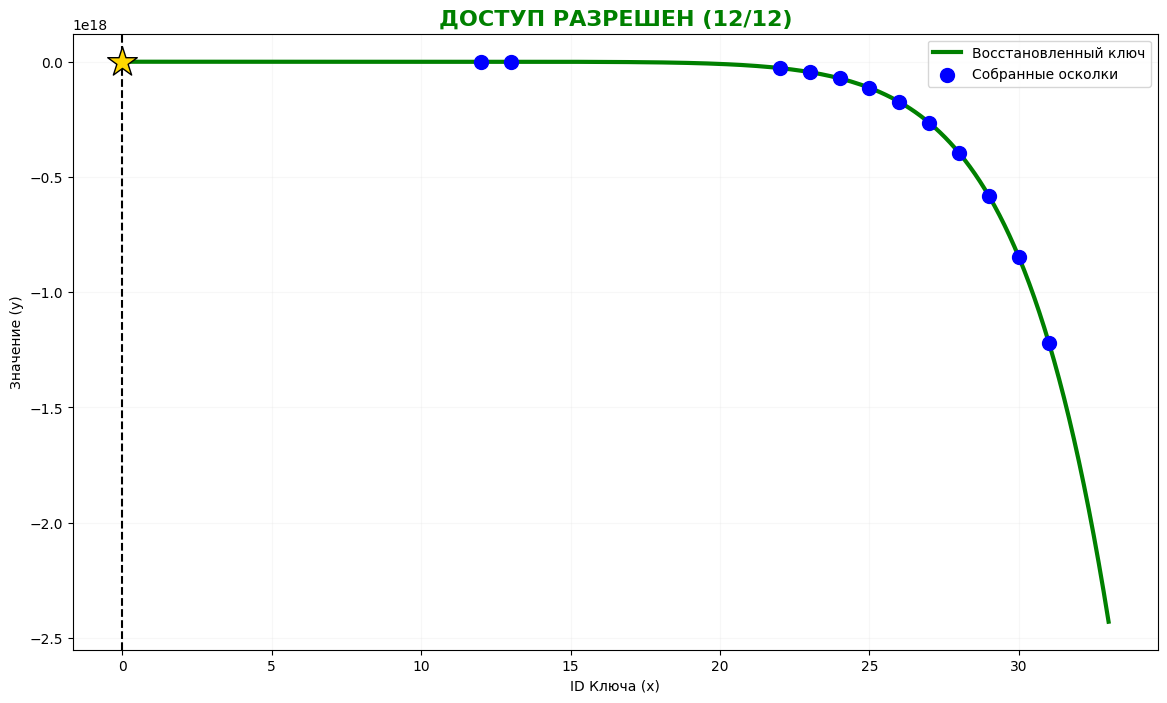


--- Сценарий 2: CEO один ---
Взлом... Не хватает 7 ключей. Генерируем фантомы.


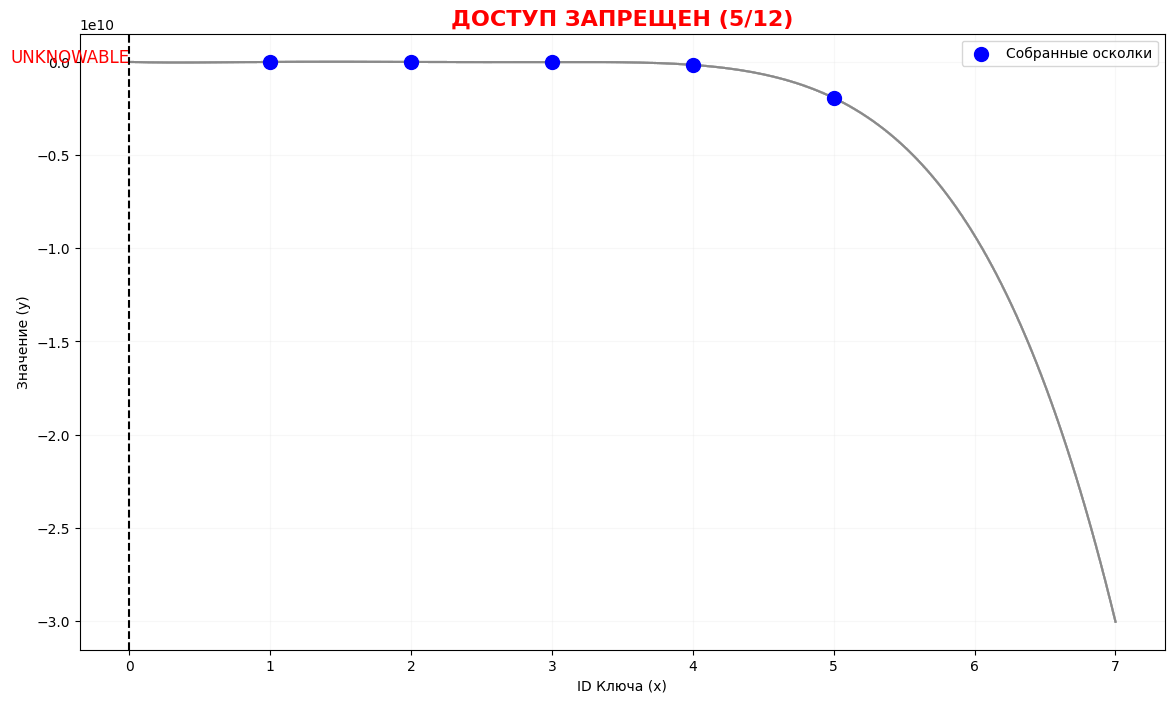


--- Сценарий 3: Переворот (11 из 12) ---
Взлом... Не хватает 1 ключей. Генерируем фантомы.


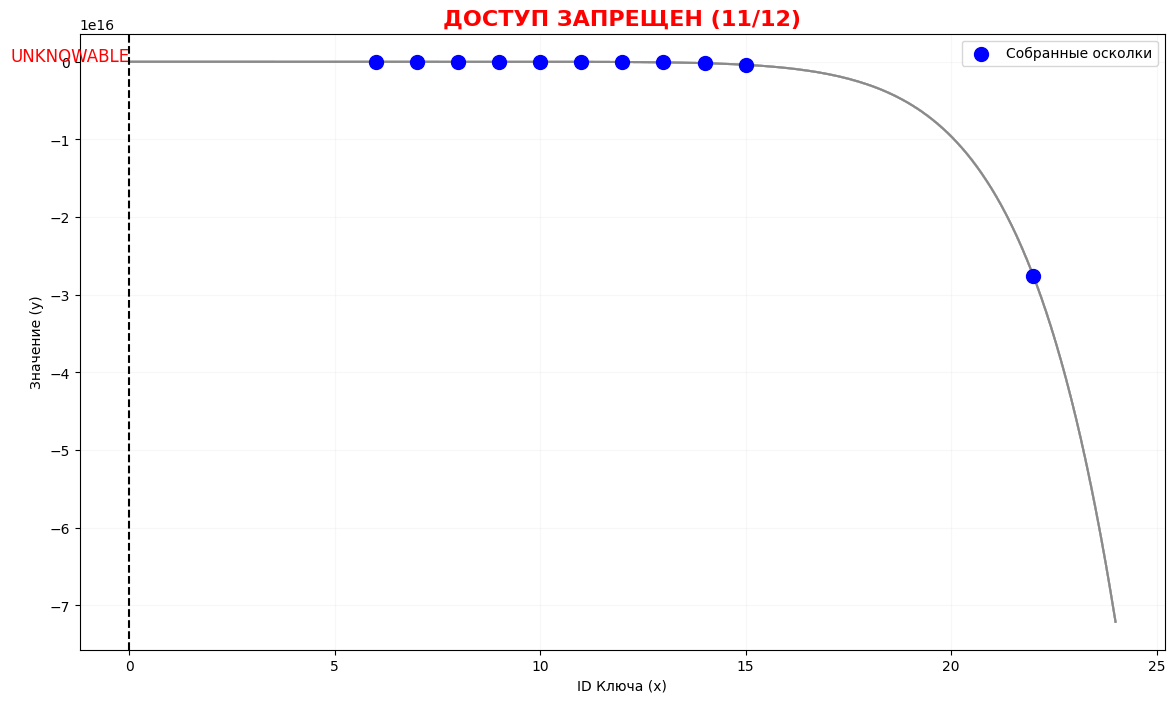

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
from numpy.polynomial.polynomial import Polynomial
import random

# Настройки стиля
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'grid.color': '#E6E6E6'})


# БЛОК 1: ядро безопасности (задание 1)

class OmegaProtocol:
    def __init__(self, secret: int, threshold):
        self.secret = secret
        self.k = threshold
        
        # --- ВАШ КОД ЗДЕСЬ (Генерация Полинома) ---
        # 1. Сгенерируйте случайные коэффициенты (random.randint) для полинома степени k-1
        # 2. Убедитесь, что свободный член (при x^0) равен self.secret
        # 3. Создайте объект полинома (np.poly1d)
        
        coeffs = [random.randint(-100, 100) for _ in range(threshold)]
        coeffs[-1] = secret
        self.poly = np.poly1d(coeffs) 
        
        # Счетчик для координат X (чтобы не выдавать одинаковые x разным людям)
        self.current_x_index = 1 

    def issue_keys(self, role_name, weight, count_people):
        """
        Выдает ключи группе людей.
        role_name: название роли (например, "CEO")
        weight: сколько точек (осколков) получает один человек этой роли
        count_people: сколько людей в этой роли
        """
        issued = {}
        for i in range(1, count_people + 1):
            person_id = f"{role_name}_{i}"
            keys = []
            
            # --- ВАШ КОД ЗДЕСЬ (Раздача ключей) ---
            # Цикл должен выполниться 'weight' раз.
            # На каждой итерации:
            #   1. Берем текущий x (self.current_x_index)
            #   2. Вычисляем y = self.poly(x)
            #   3. Добавляем (x, y) в список keys
            #   4. Увеличиваем self.current_x_index на 1
            
            for i in range(weight):
                x = self.current_x_index
                y = self.poly(x)
                keys.append((x, y))
                self.current_x_index+=1
            
            issued[person_id] = keys
        return issued

# БЛОК 2: логика взлома и визуализация (задание 2)

def attempt_activation(protocol, coalition_keys):
    """
    protocol: экземпляр класса OmegaProtocol
    coalition_keys: плоский список ключей [(x1,y1), (x2,y2)...] всех собравшихся
    """
    # 1. Распаковка данных
    if not coalition_keys:
        print("Нет ключей!")
        return
        
    x_shares = np.array([k[0] for k in coalition_keys])
    y_shares = np.array([k[1] for k in coalition_keys])
    total_power = len(x_shares) # Мощность собранной коалиции
    
    plt.figure(figsize=(14, 8))
    
    # Область отрисовки (по оси X)
    x_plot = np.linspace(0, max(x_shares) + 2, 200)
    
    # --- ВЕТКА 1: НЕДОСТАТОЧНО ПРАВ (FAIL) ---
    if total_power < protocol.k:
        status = f"ДОСТУП ЗАПРЕЩЕН ({total_power}/{protocol.k})"
        color_status = "red"
        
        print(f"Взлом... Не хватает {protocol.k - total_power} ключей. Генерируем фантомы.")
        
        # --- ВАШ КОД ЗДЕСЬ (Визуализация неопределенности) ---
        # Задача: Показать, что секретом может быть ЧТО УГОДНО.
        # Цикл 20 раз:
        #   1. Придумайте fake_secret (случайное число в диапазоне secret +/- 50%)
        #   2. Добавьте точку (0, fake_secret) к массивам x_shares, y_shares
        #   3. Постройте интерполяционный полином через эти точки (np.polyfit степени len-1)
        #   4. Нарисуйте линию (plt.plot) серым цветом (alpha=0.1)
        
        for i in range(20):
            fake_secret = random.randint(int(protocol.secret*0.5), int(protocol.secret*1.5))
            xf = np.append(x_shares, 0)
            yf = np.append(y_shares, fake_secret)
            coeffs = np.polyfit(xf, yf, len(xf)-1)
            poly_f = np.poly1d(coeffs)
            yf_plot = poly_f(x_plot)
            plt.plot(x_plot, yf_plot, color='gray', alpha=0.1)
        plt.text(0, protocol.secret, "UNKNOWABLE", fontsize=12, color='red', ha='right')

    # --- ВЕТКА 2: ДОСТАТОЧНО ПРАВ (SUCCESS) ---
    else:
        status = f"ДОСТУП РАЗРЕШЕН ({total_power}/{protocol.k})"
        color_status = "green"
        
        # --- ВАШ КОД ЗДЕСЬ (Восстановление) ---
        # 1. используйте lagrange из scipy.interpolate
        # 2. Важно: передайте в lagrange ТОЛЬКО первые k точек (protocol.k)
        # 3. Преобразуйте результат в Polynomial и вычислите значения для x_plot
        xs = x_shares[:protocol.k]
        ys = y_shares[:protocol.k]
        poly_lagrange = lagrange(xs, ys)
        poly_lagrange = Polynomial(poly_lagrange.coef[::-1])
        y_recon = poly_lagrange(x_plot)
        
        plt.plot(x_plot, y_recon, color='green', linewidth=3, label='Восстановленный ключ')
        plt.scatter(0, protocol.secret, s=500, marker='*', color='gold', edgecolors='black', zorder=10)

    # Оформление графика
    plt.scatter(x_shares, y_shares, s=100, color='blue', zorder=5, label=f'Собранные осколки')
    plt.title(status, fontsize=16, color=color_status, fontweight='bold')
    plt.axvline(0, color='black', linestyle='--')
    plt.xlabel("ID Ключа (x)"); plt.ylabel("Значение (y)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# БЛОК 3: сценарии (ЗАПУСК)

# инициализация (Секрет = 42000, Порог = 12)
# Важно: Код упадет здесь, если вы не реализовали __init__ класса!
try:
    OMEGA = OmegaProtocol(secret=42000, threshold=12)
except Exception as e:
    print(f"Ошибка инициализации: {e}")
    exit()

# Раздача ключей
ceo_keys = OMEGA.issue_keys("CEO", weight=5, count_people=1)       
top_keys = OMEGA.issue_keys("TopMngr", weight=3, count_people=2)   
sen_keys = OMEGA.issue_keys("Senior", weight=2, count_people=5)    
int_keys = OMEGA.issue_keys("Intern", weight=1, count_people=10)   

# --- сценарий 1: БУНТ СТАЖЕРОВ ---
# 10 Стажеров (10) + 1 Сеньор (2) = 12. (Должен быть УСПЕХ)
print("\n--- Сценарий 1: Бунт ---")
rebels = []
for k in int_keys.values(): rebels.extend(k) 
rebels.extend(sen_keys["Senior_1"])          

attempt_activation(OMEGA, rebels)


# --- сценарий 2: одинокий ВОЛК ---
# Только CEO (5). (Должен быть ПРОВАЛ + Веер линий)
print("\n--- Сценарий 2: CEO один ---")
wolf_pack = []
wolf_pack.extend(ceo_keys["CEO_1"])

attempt_activation(OMEGA, wolf_pack)


# --- сценарий 3: совет директоров (БЕЗ CEO) ---
# 2 Топа (6) + 2 Сеньора (4) + 1 Стажер (1) = 11. (Должен быть ПРОВАЛ)
# Обратите внимание, как близко линии подойдут к секрету, но не совпадут!
print("\n--- Сценарий 3: Переворот (11 из 12) ---")
board = []
for k in top_keys.values(): board.extend(k)
board.extend(sen_keys["Senior_1"])
board.extend(sen_keys["Senior_2"])
board.extend(int_keys["Intern_1"])

attempt_activation(OMEGA, board)

<a name="function_several_variables"></a>
## **<font color=#FF6100>2. Раздел: функции нескольких переменных**

In [6]:
import numpy as np
from numpy import pi as Pi_, cos as Cos_, sin as Sin_, exp as Exp_, sqrt as Sqrt_, log as Log_, arccos as Arccos_, tan as Tan_, arctan as Atan_, arcsin as Asin_
import matplotlib.pyplot as plt
import math
import plotly.graph_objects as go
import sympy as sp
from sympy import Symbol, symbols, diff, solve, Eq, nsolve, solveset, integrate, Integral, Function, latex, S, simplify, fraction, Union, Interval, intersection, limit, plot, Piecewise, Curve, plot_parametric, plot_implicit, And, nonlinsolve, Matrix, factor, lambdify
from sympy.calculus.util import continuous_domain
from sympy.plotting import plot3d
from sympy.geometry import Point
from sympy import sin as Sin, cos as Cos, tan as Tan, exp as Exp, log as Log, pi as Pi, sqrt as Sqrt, asin as Asin, atan as Atan, oo as Infinity, acos as Acos
%matplotlib inline

<a name="function_several_variables_1_part"></a>
### <font color=#FF6100>Область определения, предел и непрерывность, приращение и дифференциал

<a name="task_3"></a>
**<font color=#FF5EDD>Задача 3**</font>

Вы выступаете в роли аудитора DeFi-протокола. 

Разработчики заявляют, что при минимизации издержек сети (комиссии $g$ и времени блока $t$) эффективность системы стремится к максимуму ($100\%$). Однако архитектура протоколов в многомерном пространстве параметров часто таит в себе неопределенности. Вам необходимо проверить, является ли предел эффективности стабильным или он зависит от стратегии масштабирования сети.

Математическая модель: Функция эффективности протокола (Efficiency Score) задана уравнением:$$E(g, t) = (\cos g)^{\frac{1}{t^2}}$$Где:$g$ — средняя стоимость газа (Gas price), $g \to 0$.$t$ — время финализации блока (Time to finality), $t \to 0$.

*Задание 1: Проверка на устойчивость (Повторные пределы)*

Прежде чем запускать масштабный тест, необходимо проверить, как ведет себя система при поочередном изменении параметров.
* Вычислите предел функции при условии, что комиссия уже обнулена ($g = 0$), а время блока $t$ стремится к 0.
* Вычислите предел функции при фиксированном времени блока ($t = const$), если комиссия $g$ стремится к 0.
* Вопрос: Можно ли на основе этих данных утверждать, что общая эффективность всегда будет равна 1?

*Задание 2: масштабирование*

Предположим, что обновление сети происходит пропорционально: комиссия падает линейно в зависимости от скорости сети.Введем зависимость $g = k \cdot t$, где $k > 0$ — коэффициент пропорциональности. С помощью SymPy, вычислите предел:$$\lim_{t \to 0} E(kt, t)$$Анализ: Как значение коэффициента $k$ влияет на итоговый результат? Рассчитайте конкретные значения эффективности для $k = 1$ и $k = 3$.

*Задание 3: Моделирование сценария «L2 Scaling»*

Рассмотрим ситуацию, когда технологический апгрейд позволил радикально уменьшить время блока, но оптимизация комиссий за ним не поспевает.
* Найдите предел эффективности в случае, если комиссия затухает медленнее, чем время блока, по закону $g = \sqrt{t}$.
* Сформулируйте математический вывод: к чему придет протокол при таком сценарии масштабирования?

In [7]:
# Ваш код
t, g, k = sp.symbols('t g k')

e = (sp.cos(g))**(1/t**2)

lim1 = sp.limit(e.subs(g,0), t, 0)
lim2 = sp.limit(e.subs(t,1), g, 0)
print(lim1, lim2)
# На основе этих данных нельзя утверждать, так как при одновременном t->0 и g->0, предел не будет равен 1

e_scaled = (sp.cos(k*t))**(1/t**2)
limes = sp.limit(e_scaled, t, 0)
limesk1 = limes.subs(k, 1).evalf()
limesk3 = limes.subs(k, 3).evalf()
print(limes, limesk1, limesk3)

esqrt = (sp.cos(sp.sqrt(t)))**(1/t**2)
limL2 = sp.limit(esqrt, t, 0)
print(limL2)
# Эффективность стремится к 0, если комиссия уменьшается медленнее, чем время

1 1
exp(-k**2/2) 0.606530659712633 0.0111089965382423
0


<a name="task_4"></a>
**<font color=#FF5EDD>Задача 4**</font> 

*Уровень пыльцы*

В тихом и уютном городке под названием «Долина математиков» раскинулся плодовый сад. Координаты его — $(0,0)$, то есть прямо в центре мира (по мнению местных пчёл). С наступлением весны здесь происходит настоящее буйство цветения, а вместе с ним — и великое нашествие пыльцы.

Математик Аркадий, вдохновлённый не только красотой природы, но и мощным чиханием, вывел формулу, которая описывает пыльцевой индекс — показатель того, насколько сильно здесь может заложить нос:

$$
f(x, y) = \frac{\sin(x^3 y)}{x^2 + y^2}
$$

- Здесь $(x, y)$ — это Ваши координаты.
- В числителе — $\sin(x^3 y)$ — не просто синус, а синус со странностями: он отражает таинственные колебания пыльцевого потока, зависящие от того, как именно Вы отклонились от центра.
- В знаменателе — $x^2 + y^2$, и он напоминает нам, что чем дальше вы убегаете от сада, тем больше пыльца начинает лениться и оседать.

Но есть одно но: в самом центре — в точке $(0,0)$ — происходит что-то загадочное. Формула там *не определена* — ведь мы получаем $\tfrac{0}{0}$, математическую версию «мы не уверены, но возможно произойдёт пыльцевой апокалипсис».

Аркадий решил ответить на волнующий всех чихающих математиков вопрос:  
«А что вообще происходит с пыльцевым индексом *вблизи* центра? Он стремится к чему-то конкретному?»

Помогите Аркадию:)

In [8]:
# Ваш код здесь
answer_4 = 0 # вместо нуля запишите значение пыльцевого индекса в самом центре. Если его не существует, запишите -1000
r, t = sp.symbols('r theta')
x = r*Cos(t)
y = r*Sin(t)
f = sp.sin(x**3*y)/(x**2+y**2)
f_polar = f.simplify()
res = sp.limit(f_polar, r, 0)
answer_4 = res
print(answer_4)

0


<a name="task_5"></a>
**<font color=#FF5EDD>Задача 5**</font> 

Вам дана следующая функция:
$$
f(x, y) = \ln\left(\frac{x}{y}\right) + x + y
$$
1. Построить линии уровня.
2. Найти полный дифференциал функции.

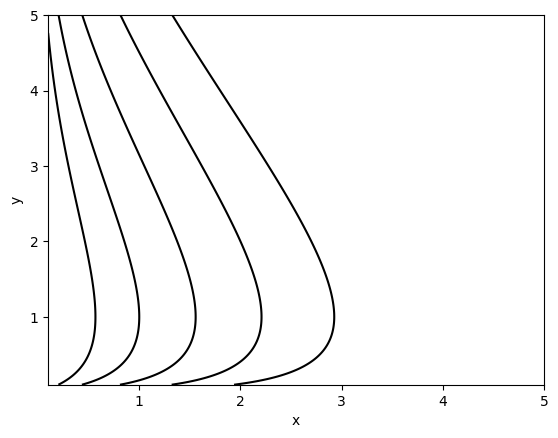

dx*(1 + 1/x) + dy*(1 - 1/y)


In [9]:
x, y = symbols('x y')
dx, dy = symbols('dx dy')

f_5 = Log(x/y) + x + y
answer_5 = sp.diff(f_5, x)*dx + sp.diff(f_5, y)*dy

x_v = np.linspace(0.1, 5, 400)
y_v = np.linspace(0.1, 5, 400)
X, Y = np.meshgrid(x_v, y_v)
F_5 = np.log(X/Y) + X + Y
plt.contour(X, Y, F_5, levels=[1,2,3,4,5], colors='black')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
print(answer_5)